In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Data inladen
# ============================================================

data_dir = "./data"

EEG = np.load(f"{data_dir}/EEG_all_epochs.npy", allow_pickle=True)
EOG = np.load(f"{data_dir}/EOG_all_epochs.npy", allow_pickle=True)
EMG = np.load(f"{data_dir}/EMG_all_epochs.npy", allow_pickle=True)


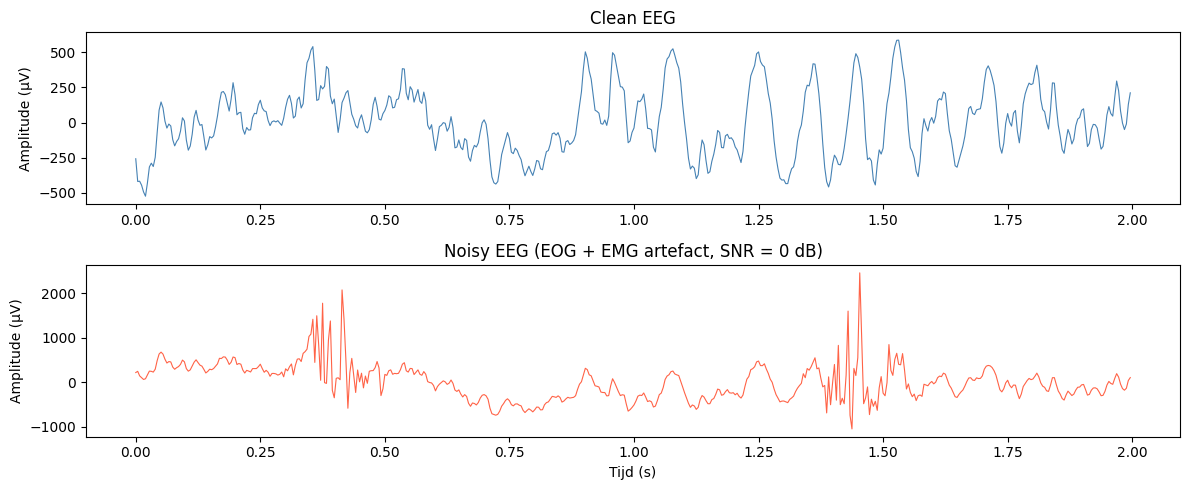

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def synthesize_noisy_eeg(EEG, EOG, EMG, snr_db=0, seed=42):
    rng = np.random.default_rng(seed)
    n = min(len(EEG), len(EOG), len(EMG))

    eeg_idx = rng.choice(len(EEG), size=n, replace=False)
    eog_idx = rng.choice(len(EOG), size=n, replace=False)
    emg_idx = rng.choice(len(EMG), size=n, replace=False)

    clean = EEG[eeg_idx]
    eog   = EOG[eog_idx]
    emg   = EMG[emg_idx]

    # Schaal beide artefacten naar gewenst SNR
    eeg_power   = np.mean(clean ** 2, axis=1, keepdims=True)
    
    eog_power   = np.mean(eog ** 2, axis=1, keepdims=True)
    eog_scale   = np.sqrt(eeg_power / (eog_power * 10 ** (snr_db / 10)))

    emg_power   = np.mean(emg ** 2, axis=1, keepdims=True)
    emg_scale   = np.sqrt(eeg_power / (emg_power * 10 ** (snr_db / 10)))

    noisy = clean + eog_scale * eog + emg_scale * emg

    return noisy, clean


# Synthetiseer
noisy, clean = synthesize_noisy_eeg(EEG, EOG, EMG, snr_db=0)

fs = 256
t = np.arange(512) / fs

fig, axes = plt.subplots(2, 1, figsize=(12, 5))

axes[0].plot(t, clean[0], color="steelblue", linewidth=0.8)
axes[0].set_title("Clean EEG")
axes[0].set_ylabel("Amplitude (µV)")

axes[1].plot(t, noisy[0], color="tomato", linewidth=0.8)
axes[1].set_title("Noisy EEG (EOG + EMG artefact, SNR = 0 dB)")
axes[1].set_ylabel("Amplitude (µV)")
axes[1].set_xlabel("Tijd (s)")

plt.tight_layout()
plt.show()